# RQ2 — Restructured Analysis

Unit of analysis: **org × procedure × stage**  
Outcome: **count of distinct ALIGNED provisions** per org per stage  

No alignment rates. No OPPOSING in the denominator.

Structure:
1. Load and build org-level dataset
2. Provision landscape — which provisions attracted the most correspondence
3. Within-org paired comparison — does aligned provision count change across stages?
4. Count regression — does meeting intensity predict aligned provision count?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130

LABEL_COLORS = {
    'ALIGNED':      '#2ecc71',
    'OPPOSING':     '#e74c3c',
    'NOISE':        '#bdc3c7',
    'UNDETECTABLE': '#95a5a6',
}
STAGE_COLORS = {'preproposal': '#3498db', 'amendment': '#e67e22'}

PROC_LABELS = {
    '2021:0106COD': 'AI Act',
    '2020:0361COD': 'DSA',
    '2020:0374COD': 'DMA',
    '2023:0212COD': 'Digital Euro',
    '2023:0284COD': 'ELV',
    '2025:0102COD': 'CMA',
    '2022:0051COD': 'CSDDD',
    '2022:0277COD': 'EMFA',
    '2022:0396COD': 'PPWR',
}

BASE = 'analysis'

## 1. Load data

For procedures with multiple dated files, pick the most recent one (latest date in filename).  
Normalise column names across pre-proposal and amendment formats.

In [2]:
def latest_dyad_file(pdir, stage_prefix):
    """Return path to most recent *_dyads.csv for a given stage prefix."""
    candidates = [
        f for f in os.listdir(pdir)
        if f.startswith(stage_prefix) and f.endswith('_dyads.csv')
    ]
    if not candidates:
        return None
    return os.path.join(pdir, sorted(candidates)[-1])  # latest date wins


def load_dyads(path, stage, proc):
    df = pd.read_csv(path)
    df['stage'] = stage
    df['procedure'] = proc
    df['proc_label'] = PROC_LABELS.get(proc, proc)

    # Normalise provision identifier to a single column
    if 'article_number' in df.columns:
        df['provision_id'] = df['article_number'].astype(str)
    elif 'amendment_number' in df.columns:
        df['provision_id'] = df['amendment_number'].astype(str)

    # Normalise meeting column names
    if 'preproposal_meetings_total' in df.columns:
        df = df.rename(columns={
            'preproposal_meetings_total':      'meetings_total',
            'preproposal_meetings_commission': 'meetings_commission',
            'preproposal_meetings_ep':         'meetings_ep',
        })

    # Only keep HYS-sourced rows (drop commission_meeting source if present)
    if 'source_type' in df.columns:
        df = df[df['source_type'].isna() | (df['source_type'] == 'hys_feedback')]

    keep = ['organisation', 'transparency_reg_id', 'meetings_total',
            'meetings_commission', 'meetings_ep',
            'provision_id', 'similarity_score', 'label',
            'stage', 'procedure', 'proc_label']
    return df[[c for c in keep if c in df.columns]].copy()


dfs = []
for proc_dir in sorted(os.listdir(BASE)):
    pdir = os.path.join(BASE, proc_dir)
    if not os.path.isdir(pdir) or ':' not in proc_dir:
        continue
    # Skip duplicate folders with parentheses in name
    if '(' in proc_dir:
        continue
    for stage, prefix in [('preproposal', 'preproposal'), ('amendment', 'amendment')]:
        path = latest_dyad_file(pdir, prefix)
        if path:
            dfs.append(load_dyads(path, stage, proc_dir))

all_dyads = pd.concat(dfs, ignore_index=True)

# Step 2: access-based filtering — only orgs with ≥1 disclosed meeting
n_before = len(all_dyads)
all_dyads = all_dyads[all_dyads['meetings_total'] > 0]
print(f'Dropped {n_before - len(all_dyads):,} dyads from orgs with 0 meetings '
      f'({n_before - len(all_dyads)}/{n_before} = {(n_before - len(all_dyads))/n_before*100:.1f}%)')

print(f'Total dyads: {len(all_dyads):,}')
print(f'Procedures:  {all_dyads["proc_label"].nunique()}')
print()
print(all_dyads.groupby(['proc_label', 'stage'])['label'].value_counts().unstack(fill_value=0))

Dropped 1,359 dyads from orgs with 0 meetings (1359/9161 = 14.8%)
Total dyads: 7,802
Procedures:  9

label                     ALIGNED  NOISE  OPPOSING  UNDETECTABLE
proc_label   stage                                              
AI Act       amendment        159    223        70            78
             preproposal       43     56        14            29
CMA          amendment        384    198        84           121
             preproposal        7      6         0             3
CSDDD        amendment        198    175       116            79
             preproposal       17      3         1             3
DMA          amendment        496    428       120           184
             preproposal       25     26         0             9
DSA          amendment        447    554       211           253
             preproposal       74     58        16            30
Digital Euro amendment        225    200       104           170
ELV          amendment        406    282       126    

## 2. Build org-level dataset

Collapse from dyad level to **org × procedure × stage**.  
Key columns:
- `count_aligned` — distinct provisions with ALIGNED label  
- `total_provisions` — distinct provisions appearing in *any* dyad for this org/proc/stage (used as exposure)
- `meetings_total` — access measure

In [3]:
def org_level(df):
    return df.groupby(['organisation', 'procedure', 'proc_label', 'stage']).agg(
        meetings_total    = ('meetings_total', 'first'),
        meetings_comm     = ('meetings_commission', 'first'),
        meetings_ep       = ('meetings_ep', 'first'),
        count_aligned     = ('label', lambda x: (x == 'ALIGNED').sum()),
        count_opposing    = ('label', lambda x: (x == 'OPPOSING').sum()),
        count_noise       = ('label', lambda x: (x == 'NOISE').sum()),
        count_undetect    = ('label', lambda x: (x == 'UNDETECTABLE').sum()),
        total_dyads       = ('label', 'count'),
        # distinct provisions this org matched (our exposure)
        n_provisions_matched = ('provision_id', 'nunique'),
    ).reset_index()

orgs = org_level(all_dyads)

# Total distinct provisions per procedure × stage across ALL orgs
# (corpus exposure — how many provisions were searchable)
corpus_size = (
    all_dyads.groupby(['procedure', 'stage'])['provision_id']
    .nunique()
    .reset_index(name='corpus_provisions')
)
orgs = orgs.merge(corpus_size, on=['procedure', 'stage'], how='left')

# Coverage: share of corpus provisions this org aligned with
orgs['coverage'] = orgs['count_aligned'] / orgs['corpus_provisions']

print(f'Org × procedure × stage rows: {len(orgs):,}')
print(f'Unique orgs: {orgs["organisation"].nunique()}')
print()
print(orgs.groupby(['proc_label', 'stage'])[['count_aligned', 'corpus_provisions', 'meetings_total']]
      .agg(['mean', 'median', 'max']).round(1))

Org × procedure × stage rows: 326
Unique orgs: 290

                         count_aligned            corpus_provisions         \
                                  mean median max              mean median   
proc_label   stage                                                           
AI Act       amendment            14.5   13.0  36             347.0  347.0   
             preproposal           2.9    2.0  15              58.0   58.0   
CMA          amendment            19.2   18.0  74             377.0  377.0   
             preproposal           1.8    1.5   3              13.0   13.0   
CSDDD        amendment             4.6    3.0  22             237.0  237.0   
             preproposal           3.4    3.0   7              13.0   13.0   
DMA          amendment            17.7    8.5  92             588.0  588.0   
             preproposal           2.8    2.0  10              24.0   24.0   
DSA          amendment            11.5    8.0  34             616.0  616.0   
            

## 3. Count regression

**What is a count model?**

Normal linear regression predicts a continuous outcome. Here the outcome (`count_aligned`) is  
a non-negative integer: 0, 1, 2, 3... This violates linear regression assumptions (can't be  
negative, often has many zeros, variance tends to grow with the mean).

**Negative binomial regression** is designed for count outcomes. It models  
`E[count] = exp(β₀ + β₁x₁ + ...)`, so predictions are always positive.  
Coefficients are interpreted as: a unit increase in x multiplies the expected count by `exp(β)`.

**Offset term**: because amendment stages have far more provisions than pre-proposal stages,  
we include `log(corpus_provisions)` as an offset. This turns the model into predicting  
*rate* (aligned provisions per searchable provision) rather than raw count.

**Three specifications:**  
- Model 1: meetings only  
- Model 2: meetings + stage + procedure fixed effects  
- Model 3: meetings + stage + interaction + procedure fixed effects  

In [10]:
# ── Prepare regression dataset ─────────────────────────────────────────────
reg = orgs.copy()
reg = reg[reg['corpus_provisions'] > 0].copy()

reg['log_meetings']    = np.log1p(reg['meetings_total'])
reg['is_preproposal']  = (reg['stage'] == 'preproposal').astype(int)
reg['log_corpus']      = np.log(reg['corpus_provisions'])  # offset
reg['interaction']     = reg['log_meetings'] * reg['is_preproposal']

# Sanitise proc_label for use as formula tokens (replace spaces/slashes with underscore)
reg['proc_label_clean'] = reg['proc_label'].str.replace(r'[^A-Za-z0-9]', '_', regex=True)
reg = pd.get_dummies(reg, columns=['proc_label_clean'], drop_first=True, dtype=float)

proc_dummies = [c for c in reg.columns if c.startswith('proc_label_clean_')]

print(f'Regression sample: {len(reg)} org×procedure×stage rows')
print(f'Orgs with 0 aligned provisions: {(reg["count_aligned"]==0).sum()} '
      f'({(reg["count_aligned"]==0).mean()*100:.1f}%)')
print(f'Mean count_aligned: {reg["count_aligned"].mean():.2f}')
print(f'Variance:           {reg["count_aligned"].var():.2f}  '
      f'(if >> mean → overdispersed → use NegBin)')
print(f'Procedure dummies: {proc_dummies}')

Regression sample: 326 org×procedure×stage rows
Orgs with 0 aligned provisions: 41 (12.6%)
Mean count_aligned: 9.11
Variance:           151.20  (if >> mean → overdispersed → use NegBin)
Procedure dummies: ['proc_label_clean_CMA', 'proc_label_clean_CSDDD', 'proc_label_clean_DMA', 'proc_label_clean_DSA', 'proc_label_clean_Digital_Euro', 'proc_label_clean_ELV', 'proc_label_clean_EMFA', 'proc_label_clean_PPWR']


In [11]:
# ── Fit negative binomial models ───────────────────────────────────────────
# statsmodels NegativeBinomial with exposure (offset)

def fit_negbin(formula_rhs, data, offset_col='log_corpus'):
    formula = f'count_aligned ~ {formula_rhs}'
    y = data['count_aligned'].values
    X = sm.add_constant(
        data[[c for c in data.columns
              if c in formula_rhs or any(c == p for p in proc_dummies)]]
    )
    return None  # placeholder — use smf below

# Build formulas
proc_fe = ' + '.join(proc_dummies) if proc_dummies else '0'

formula1 = 'count_aligned ~ log_meetings'
formula2 = f'count_aligned ~ log_meetings + is_preproposal + {proc_fe}'
formula3 = f'count_aligned ~ log_meetings + is_preproposal + interaction + {proc_fe}'

models = {}
for name, formula in [('Model 1 (meetings only)', formula1),
                       ('Model 2 (+ stage + proc FE)', formula2),
                       ('Model 3 (+ interaction)', formula3)]:
    m = smf.negativebinomial(formula, data=reg, exposure=reg['corpus_provisions']).fit(
        disp=False, method='nm', maxiter=500
    )
    models[name] = m
    print(f'\n=== {name} ===')
    core_params = ['Intercept', 'log_meetings', 'is_preproposal', 'interaction']
    show = m.params.index[m.params.index.isin(core_params)]
    summary = pd.DataFrame({
        'coef':    m.params[show].round(3),
        'exp(coef) = IRR': np.exp(m.params[show]).round(3),
        'p':       m.pvalues[show].round(3),
    })
    print(summary.to_string())
    print(f'  Pseudo-R²: {1 - m.llf/m.llnull:.3f}')


=== Model 1 (meetings only) ===
               coef  exp(coef) = IRR      p
Intercept    -3.691            0.025  0.000
log_meetings  0.197            1.217  0.037
  Pseudo-R²: 0.002

=== Model 2 (+ stage + proc FE) ===
                 coef  exp(coef) = IRR      p
Intercept      -4.086            0.017  0.000
log_meetings    0.289            1.335  0.001
is_preproposal  1.339            3.816  0.000
  Pseudo-R²: 0.052

=== Model 3 (+ interaction) ===
                 coef  exp(coef) = IRR      p
Intercept      -4.120            0.016  0.000
log_meetings    0.324            1.382  0.000
is_preproposal  1.999            7.380  0.000
interaction    -0.526            0.591  0.063
  Pseudo-R²: 0.053


## 4. Summary table for thesis

Compact table showing key stats per procedure × stage — suitable for Table 4.4 replacement.

In [14]:
summary = (
    orgs.groupby(['proc_label', 'stage'])
    .agg(
        n_orgs           = ('organisation', 'nunique'),
        corpus_provs     = ('corpus_provisions', 'first'),
        median_aligned   = ('count_aligned', 'median'),
        mean_aligned     = ('count_aligned', 'mean'),
        orgs_any_aligned = ('count_aligned', lambda x: (x > 0).sum()),
        median_meetings  = ('meetings_total', 'median'),
    )
    .round(1)
    .reset_index()
)
summary['pct_orgs_aligned'] = (summary['orgs_any_aligned'] / summary['n_orgs'] * 100).round(1)

print('Key stats per procedure × stage:')
print(summary.to_string(index=False))

Key stats per procedure × stage:
  proc_label       stage  n_orgs  corpus_provs  median_aligned  mean_aligned  orgs_any_aligned  median_meetings  pct_orgs_aligned
      AI Act   amendment      11           347            13.0          14.5                 9              6.0              81.8
      AI Act preproposal      15            58             2.0           2.9                12              2.0              80.0
         CMA   amendment      20           377            18.0          19.2                18              2.5              90.0
         CMA preproposal       4            13             1.5           1.8                 4              2.0             100.0
       CSDDD   amendment      43           237             3.0           4.6                35              2.0              81.4
       CSDDD preproposal       5            13             3.0           3.4                 4              1.0              80.0
         DMA   amendment      28           588           

## 5. Scatter grid: meetings vs aligned provisions

Per-procedure scatter of meeting count against aligned-provision count, with a log-linear trend overlaid where $n \geq 5$. Saved as `images/fig_scatter_grid.{png,pdf}` and cited in the thesis as Figure `fig:scatter_grid`.

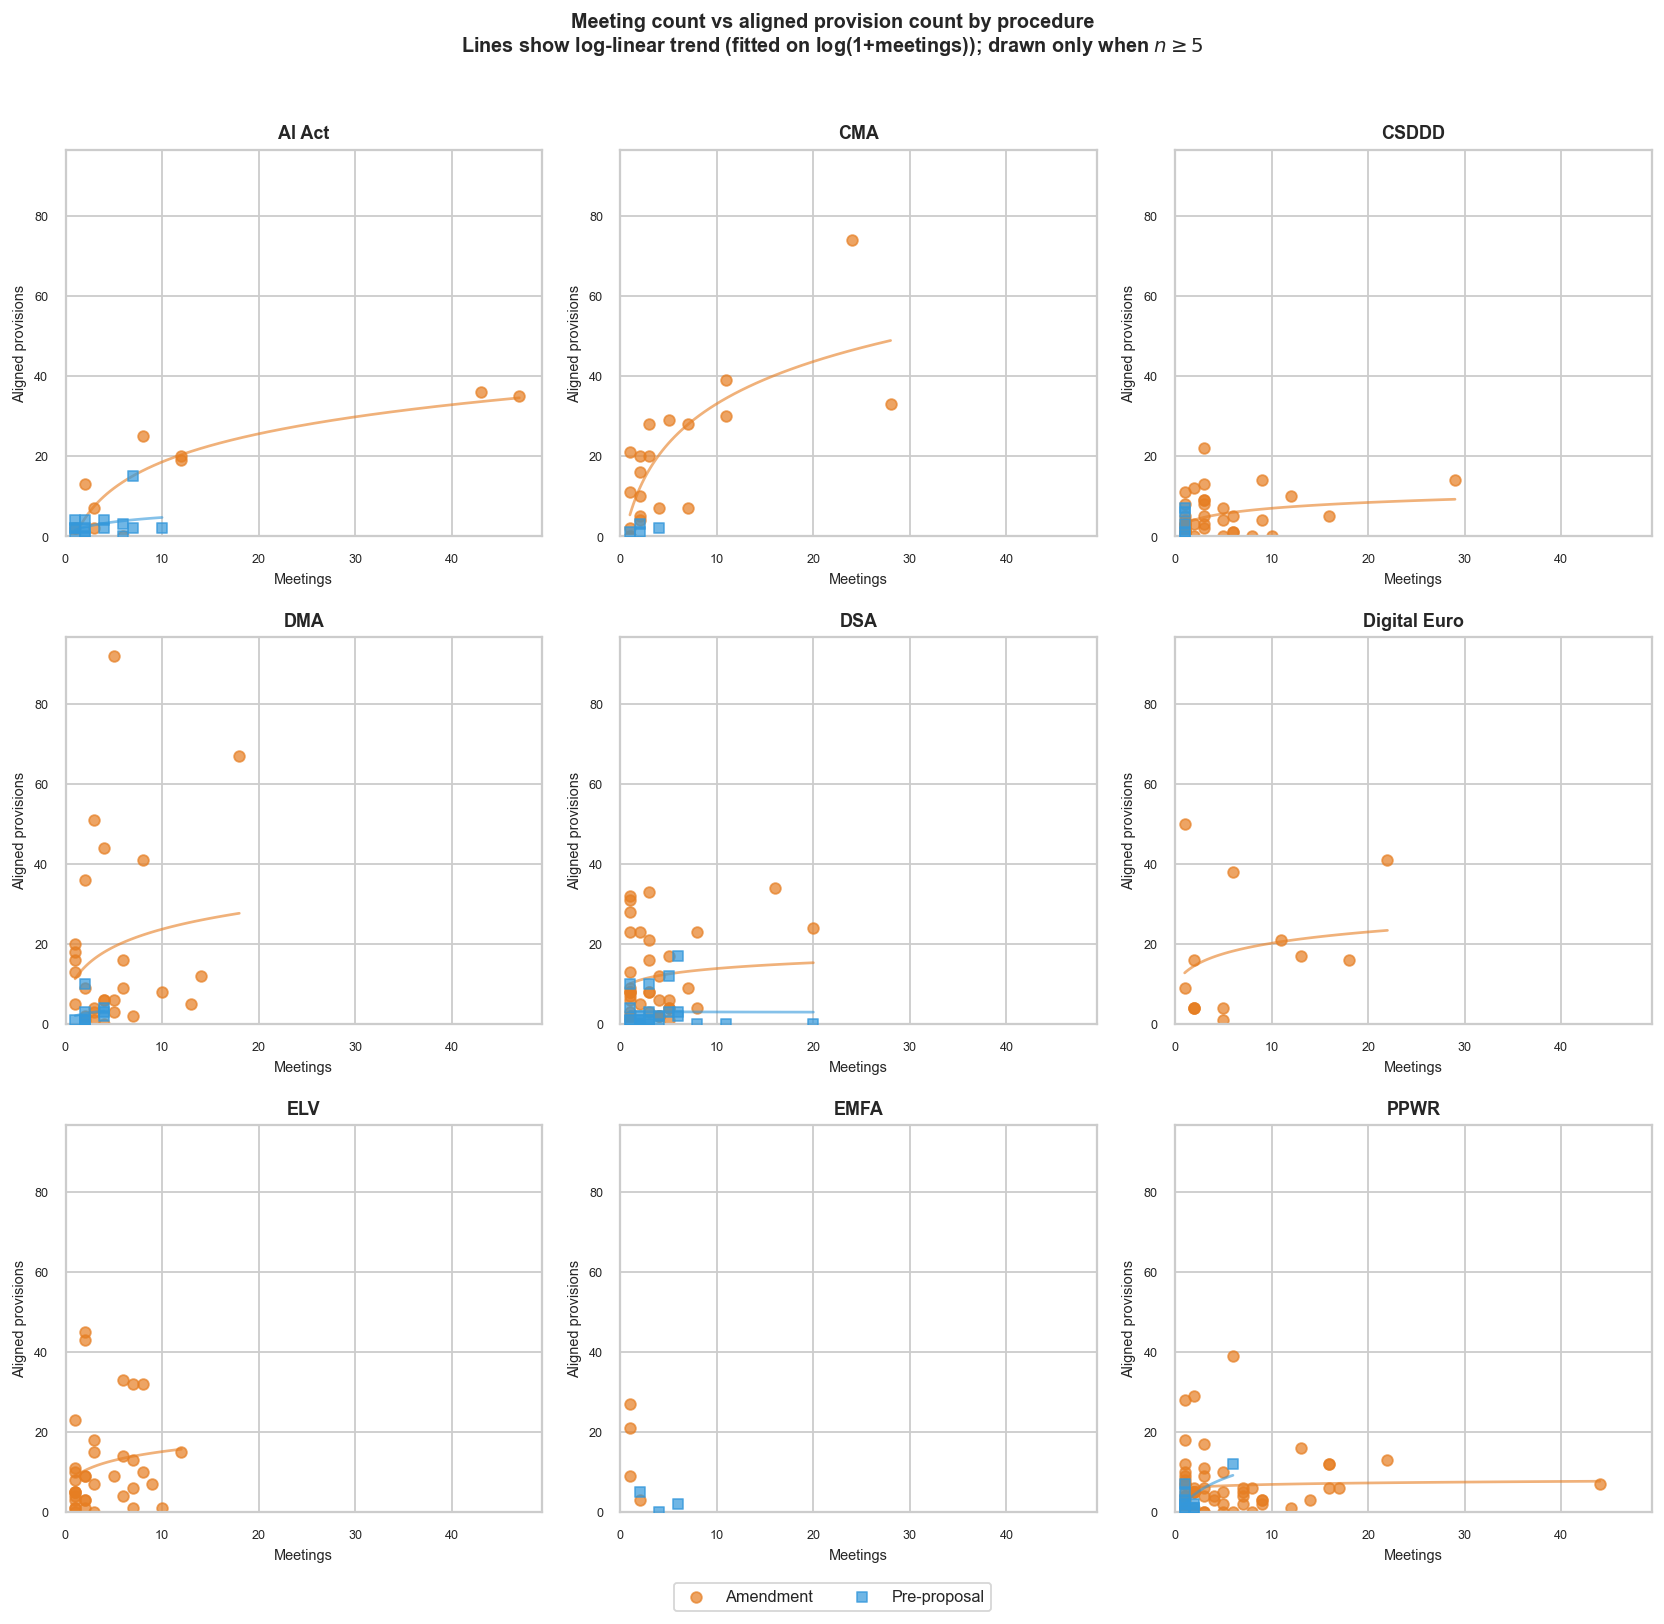

Saved fig_scatter_grid.png / .pdf


In [15]:
# 3x3 scatter grid: meetings vs aligned provision count, per procedure
# Shared axes so all panels are directly comparable
procs = sorted(orgs['proc_label'].unique())

x_max = orgs['meetings_total'].max() * 1.05
y_max = orgs['count_aligned'].max() * 1.05

fig, axes = plt.subplots(3, 3, figsize=(13, 12), sharex=False, sharey=False)
axes = axes.flatten()

for ax, proc in zip(axes, procs):
    sub = orgs[orgs['proc_label'] == proc]
    for stage, marker, zorder in [('amendment', 'o', 2), ('preproposal', 's', 3)]:
        s = sub[sub['stage'] == stage]
        ax.scatter(
            s['meetings_total'], s['count_aligned'],
            color=STAGE_COLORS[stage], alpha=0.7, s=35,
            marker=marker, zorder=zorder,
            label=stage.replace('preproposal', 'Pre-proposal').replace('amendment', 'Amendment')
        )
        x = np.log1p(s['meetings_total'])
        if len(s) >= 5 and x.std() > 0:
            y = s['count_aligned'].values.astype(float)
            xv = x.values
            coef = np.polyfit(xv, y, 1)
            x_range = np.linspace(xv.min(), xv.max(), 50)
            ax.plot(np.expm1(x_range), np.polyval(coef, x_range),
                    color=STAGE_COLORS[stage], lw=1.5, alpha=0.6)

    ax.set_xlim(0, x_max)
    ax.set_ylim(0, y_max)
    ax.set_title(proc, fontsize=10, fontweight='bold')
    ax.set_xlabel('Meetings', fontsize=8)
    ax.set_ylabel('Aligned provisions', fontsize=8)
    ax.tick_params(labelsize=7)

handles, labels = axes[0].get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
fig.legend(seen.values(), seen.keys(),
           loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Meeting count vs aligned provision count by procedure\n'
             'Lines show log-linear trend (fitted on log(1+meetings)); drawn only when $n \geq 5$',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/fig_scatter_grid.png', dpi=150, bbox_inches='tight')
plt.savefig('images/fig_scatter_grid.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_scatter_grid.png / .pdf')
